In [39]:
import pandas as pd
import nltk
import string
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prati\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [42]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [43]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [44]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [45]:
stop_words = set(stopwords.words('english'))

In [46]:
def preprocess(text):
    text = text.lower()

    text = "".join(char for char in text if char not in string.punctuation)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['message'] = df['message'].apply(preprocess)

In [47]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['message'])

y = df['label']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4457, 9376), (1115, 9376), (4457,), (1115,))

In [50]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [51]:
y_pred = model.predict(X_test)

In [52]:
for i in range(20):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 1
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 0, Actual: 0


In [53]:
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy of model: {accuracy*100:.2f} %")

Accuracy of model: 96.59 %


In [54]:
cr=classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [55]:
confMat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confMat)

Confusion Matrix:
 [[965   0]
 [ 38 112]]


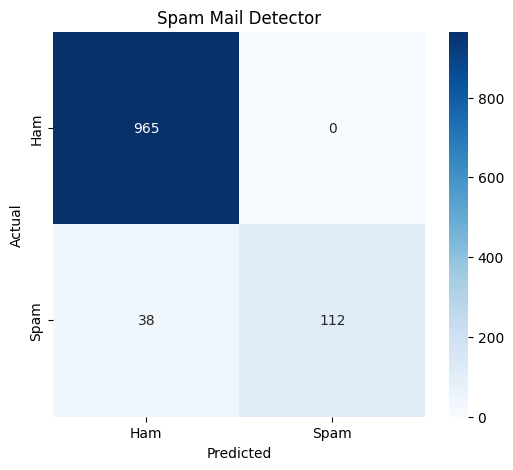

In [56]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confMat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Mail Detector")
plt.show()

In [57]:
user_text = "Congratulations! You've won a free ticket to Bahamas. Call now to claim your prize."

In [58]:
processed = preprocess(user_text)


In [59]:

vector = tfidf.transform([processed])
prediction = model.predict(vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham (Not Spam)")

Spam Message


In [62]:
user_input = input("Enter a message to check if it's spam or not: ")
processed_input = preprocess(user_input)
vector_input = tfidf.transform([processed_input])
prediction_input = model.predict(vector_input)

if prediction_input[0] == 1:
    print("Spam Message")
else:
    print("Ham (Not Spam)")

Ham (Not Spam)
